In [8]:
import gym
from gym import spaces
import numpy as np
import random
from collections import deque, namedtuple
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import matplotlib.pyplot as plt
from pythermalcomfort.models import pmv_ppd

## Building HVAC Gymnasium Environment without visualised simulation (rendering)

**IMPORTANT NOTE**:  
RARL HIL is trained in an adversarial/irrational input-free offline setting, with *simulated* adversarial/irrational input from the adversary agent, then deployed in a online setting with adversarial/irrational input

In [9]:
class BuildingEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, alpha=1, beta=1, EER=11):
        super(BuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER

        self.room_width, self.room_height = 800, 600
        self.action_space = spaces.Discrete(9)  # Temperature setpoints: 22°C to 30°C
        low = np.array([-10.0, 0.0, -3.0])  # [Outdoor Temp, Occupancy, Aggregated PMV]
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)

        # adversary action space
        # actions: 0 - No change, 1 - Increase PMV, 2 - Decrease PMV
        self.adversary_action_space = spaces.Discrete(3)

        self.time_step = 0
        self.max_steps = 48  # each step is 30 minutes, 48 steps in a day

        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()

        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': []
        }

    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)  # peaks at 2 PM
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:  # Normal work hours
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:  # Lunch hour (peak)
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:  # Transition hours
            occupancy = np.random.uniform(0.2, 0.5)
        else:  # Off hours
            occupancy = np.random.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 1.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            return 0
        pmv_values = []
        for user in self.users:
            met = user['met']
            clo = user['clo']
            pmv = self.calculate_pmv(met, clo)
            pmv_values.append(pmv)
        aggregated_pmv = np.mean(pmv_values)
        return np.clip(aggregated_pmv, -3.0, 3.0)

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp  # Dry bulb temperature
        tr = tdb  # Mean radiant temperature
        rh = 50.0  # Relative humidity
        v = 0.1  # Air velocity

        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, adversary_action):
        # protagonist's action
        self.setpoint_temp = 22 + action  #action is between 0 and 8 setpoint between 22°C and 30°C

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER 

        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        solar_gain = np.sin((time_of_day - 6) * np.pi / 12) * 0.05
        solar_gain = max(0.0, solar_gain)

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5

        self.indoor_temp += outdoor_influence + hvac_influence + solar_gain

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.nonadv_user_feedback = self.generate_user_feedback()
        self.user_feedback = self.nonadv_user_feedback
        # manipulate the user feedback
        if adversary_action == 1:
            self.user_feedback += 0.5  # how much disturbance to add
        elif adversary_action == 2:
            self.user_feedback -= 0.5  # how much disturbance to add

        self.user_feedback = np.clip(self.user_feedback, -3.0, 3.0)
        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)  
        else:
            # comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            comfort_penalty = abs(self.nonadv_user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 100.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        # NORMALIZING REWARD
        reward = reward / 10.0

        # adversary's reward is the negative of the protagonist's reward
        adversary_reward = -reward

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}, adversary_reward  # return adversary_reward for adversary's learning

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state

    def render(self):
        pass  # Rendering code if needed

# RARL algorithm

Must be changed with the hyperparameters

In [10]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 128)
        self.layer4 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

class DQNAgent:
    def __init__(self, n_observations, n_actions, device, memory_size=10000, batch_size=64, gamma=0.99, eps_start=0.9, eps_end=0.05, eps_decay=2000, tau=0.005, lr=1e-3):
        self.n_observations = n_observations
        self.n_actions = n_actions
        self.device = device
        self.batch_size = batch_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay 
        self.tau = tau
        self.lr = lr

        self.policy_net = DQN(n_observations, n_actions).to(device)
        self.target_net = DQN(n_observations, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayMemory(memory_size)

        self.steps_done = 0

    def select_action(self, state, train=True):
        if train:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                math.exp(-1. * self.steps_done / self.eps_decay)
            self.steps_done += 1
        else:
            eps_threshold = self.eps_end  
        if random.random() > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        target_net_state_dict = self.target_net.state_dict()
        policy_net_state_dict = self.policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * self.tau + \
                                         target_net_state_dict[key] * (1 - self.tau)
        self.target_net.load_state_dict(target_net_state_dict)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

In [11]:
# rarl agent, similar to DQN (protagonist agent) but with adversary actions
class AdversaryAgent(DQNAgent):
    def __init__(self, n_observations, n_actions, device):
        super().__init__(n_observations, n_actions, device, memory_size=5000, batch_size=64, gamma=0.99, eps_start=1.0, eps_end=0.05, eps_decay=10000, tau=0.005, lr=1e-3)       
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)

    def select_action(self, state, train=True):
        if train:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                math.exp(-1. * self.steps_done / self.eps_decay)
            self.steps_done += 1
        else:
            eps_threshold = self.eps_end  
        if random.random() > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)  # reward is negative of protagonist's reward

        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        target_net_state_dict = self.target_net.state_dict()
        policy_net_state_dict = self.policy_net.state_dict()
        for key in policy_net_state_dict:
            target_param = target_net_state_dict[key]
            param = policy_net_state_dict[key]
            target_net_state_dict[key] = param * self.tau + target_param * (1 - self.tau)
        self.target_net.load_state_dict(target_net_state_dict)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

# RARL algorithm training

In [12]:
import numpy as np
import torch

""" 
This train_ralr function takes several key parameters:
agent
adversary
episodes_per_switch: How many episodes each agent gets to train before switching (default 10)
target_update_frequency: How often to update the target networks (every 10 episodes)
"""
def train_rarl(agent, adversary, env, episodes, episodes_per_switch=10, target_update_frequency=10):
    def train_one(agent, adversary, train_agent, train_adversary): # basically training one episode
        state = env.reset()
        state_agent = torch.tensor([state], device=agent.device, dtype=torch.float32)
        state_adversary = torch.tensor([state], device=adversary.device, dtype=torch.float32)
        
        total_agent_reward = 0
        total_adversary_reward = 0
        agent_actions = []
        adversary_actions = []
        temps = []
        feedbacks = []

        for step in range(env.max_steps):
            action = agent.select_action(state_agent, train=train_agent)
            adversary_action = adversary.select_action(state_adversary, train=train_adversary)
            
            agent_actions.append(action.item())
            adversary_actions.append(adversary_action.item())
            temps.append(env.indoor_temp)
            feedbacks.append(env.user_feedback)
            
            next_state, reward, done, _, adversary_reward = env.step(action.item(), adversary_action.item())
            reward_tensor = torch.tensor(np.array([reward]), device=agent.device, dtype=torch.float32)
            adversary_reward_tensor = torch.tensor(np.array([adversary_reward]), device=adversary.device, dtype=torch.float32)

            if not done:
                next_state_agent = torch.tensor(np.array([next_state]), device=agent.device, dtype=torch.float32)
                next_state_adversary = torch.tensor(np.array([next_state]), device=adversary.device, dtype=torch.float32)
            else:
                next_state_agent = None
                next_state_adversary = None

            if train_agent:
                agent.memorize(state_agent, action, next_state_agent, reward_tensor)
                agent.optimize_model()
            if train_adversary:
                adversary.memorize(state_adversary, adversary_action, next_state_adversary, adversary_reward_tensor)
                adversary.optimize_model()

            state_agent = next_state_agent
            state_adversary = next_state_adversary
            total_agent_reward += reward
            total_adversary_reward += adversary_reward

            if done:
                break

        return total_agent_reward, total_adversary_reward, agent_actions, adversary_actions, temps, feedbacks

    agent_rewards = []
    adversary_rewards = []
    all_agent_actions = []
    all_adversary_actions = []
    all_temperatures = []
    all_feedback = []
    episode_number = 0

    while episode_number < episodes:
        for _ in range(episodes_per_switch):
            if episode_number >= episodes:
                break
            agent_reward, adversary_reward, agent_acts, adv_acts, temps, feedbacks = train_one(
                agent, adversary, train_agent=True, train_adversary=False
            )
            
            agent_rewards.append(agent_reward)
            adversary_rewards.append(adversary_reward)
            all_agent_actions.extend(agent_acts)
            all_adversary_actions.extend(adv_acts)
            all_temperatures.extend(temps)
            all_feedback.extend(feedbacks)
            
            episode_number += 1
            if episode_number % target_update_frequency == 0:
                agent.target_net.load_state_dict(agent.policy_net.state_dict())

        for _ in range(episodes_per_switch):
            if episode_number >= episodes:
                break
            agent_reward, adversary_reward, agent_acts, adv_acts, temps, feedbacks = train_one(
                agent, adversary, train_agent=False, train_adversary=True
            )
            
            agent_rewards.append(agent_reward)
            adversary_rewards.append(adversary_reward)
            all_agent_actions.extend(agent_acts)
            all_adversary_actions.extend(adv_acts)
            all_temperatures.extend(temps)
            all_feedback.extend(feedbacks)
            
            episode_number += 1
            if episode_number % target_update_frequency == 0:
                adversary.target_net.load_state_dict(adversary.policy_net.state_dict())

        if episode_number % 10 == 0:
            agent_action_counts = np.bincount(all_agent_actions[-env.max_steps:])
            adv_action_counts = np.bincount(all_adversary_actions[-env.max_steps:])
            
            print(f"Episode {episode_number}/{episodes}")
            print(f"Average Agent Reward: {np.mean(agent_rewards[-10:]):.2f}")
            print(f"Average Adversary Reward: {np.mean(adversary_rewards[-10:]):.2f}")
            
            print("Recent Agent Actions (Temperature Setpoints):")
            for action, count in enumerate(agent_action_counts):
                temp = 22 + action
                if count > 0:
                    print(f"  {temp}°C: {count/sum(agent_action_counts)*100:.1f}%")
            
            print("Recent Adversary Actions:")
            actions = [None, "+0.5", "-0.5"]  # Update the section labels
            for action, count in enumerate(adv_action_counts):
                if count > 0:
                    print(f"  {actions[action]}: {count/sum(adv_action_counts)*100:.1f}%")   
                             
            print(f"Average Indoor Temperature: {np.mean(all_temperatures[-env.max_steps:]):.1f}°C")
            print(f"Average User Feedback: {np.mean(all_feedback[-env.max_steps:]):.2f}")

    return {
        'agent_rewards': agent_rewards,
        'adversary_rewards': adversary_rewards,
        'agent_actions': all_agent_actions,
        'adversary_actions': all_adversary_actions,
        'temperatures': all_temperatures,
        'feedback': all_feedback
    }

def plot_rarl(results):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    ax1.plot(results['agent_rewards'], label='Agent')
    ax1.plot(results['adversary_rewards'], label='Adversary')
    ax1.set_title('Training Rewards')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.legend()
    
    temps = [22 + action for action in results['agent_actions']]
    ax2.hist(temps, bins=9, range=(22, 31))
    ax2.set_title('Temperature Setpoint Distribution')
    ax2.set_xlabel('Temperature (°C)')
    ax2.set_ylabel('Count')
    
    ax3.hist(results['adversary_actions'], bins=4, range=(0, 4))
    ax3.set_title('Adversary Action Distribution')
    ax3.set_xticks([0.5, 1.5, 2.5, 3.5])
    ax3.set_xticklabels(['+0.25', '-0.25', '+0.5', '-0.5'])
    ax3.set_ylabel('Count')
    
    ax4.hist(results['feedback'], bins=20)
    ax4.set_title('User Feedback Distribution')
    ax4.set_xlabel('Feedback Score')
    ax4.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()

/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Episode 20/365
Average Agent Reward: -1.01
Average Adversary Reward: 1.01
Recent Agent Actions (Temperature Setpoints):
  23°C: 2.1%
  26°C: 97.9%
Recent Adversary Actions:
  None: 39.6%
  +0.5: 25.0%
  -0.5: 35.4%
Average Indoor Temperature: 26.2°C
Average User Feedback: 0.74
Episode 40/365
Average Agent Reward: -0.27
Average Adversary Reward: 0.27
Recent Agent Actions (Temperature Setpoints):
  22°C: 14.6%
  23°C: 79.2%
  27°C: 2.1%
  30°C: 4.2%
Recent Adversary Actions:
  None: 20.8%
  +0.5: 45.8%
  -0.5: 33.3%
Average Indoor Temperature: 24.1°C
Average User Feedback: 0.33
Episode 60/365
Average Agent Reward: -0.53
Average Adversary Reward: 0.53
Recent Agent Actions (Temperature Setpoints):
  22°C: 39.6%
  24°C: 2.1%
  25°C: 8.3%
  28°C: 4.2%
  29°C: 45.8%
Recent Adversary Actions:
  None: 33.3%
  +0.5: 39.6%
  -0.5: 27.1%
Average Indoor Temperature: 26.0°C
Average User Feedback: 0.81
Episode 80/365
Average Agent Reward: -0.44
Average Adversary Reward: 0.44
Recent Agent Actions (Tem

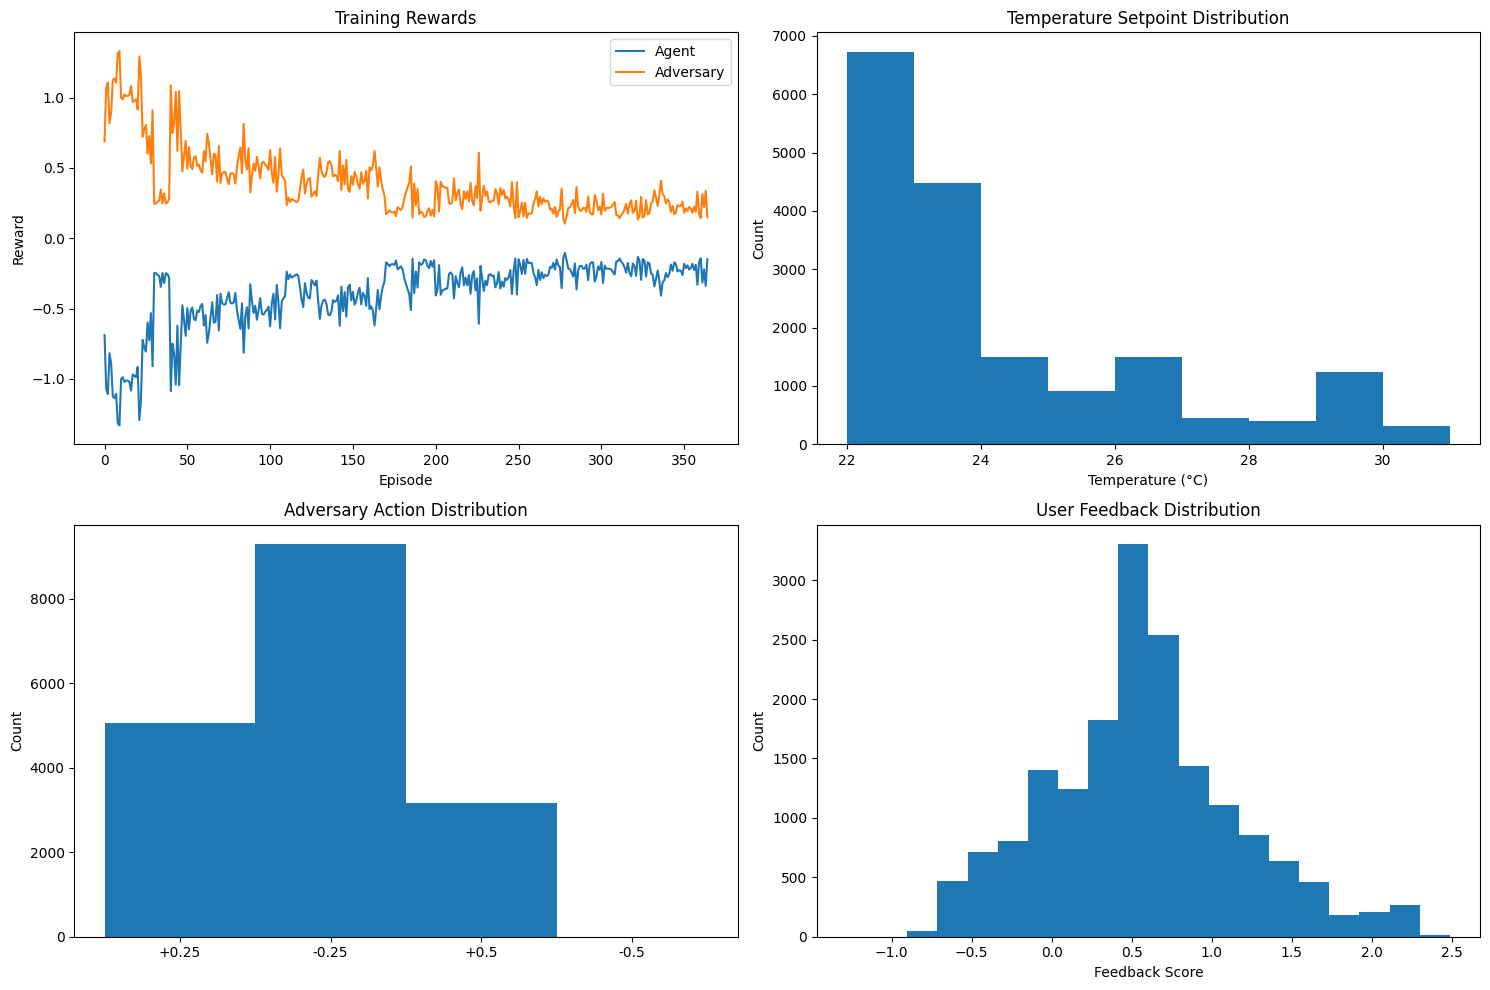

In [13]:
env = BuildingEnv()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = DQNAgent(n_observations=env.observation_space.shape[0], n_actions=env.action_space.n, device=device)
adversary = AdversaryAgent(n_observations=env.observation_space.shape[0], n_actions=env.adversary_action_space.n, device=device)
episodes = 365
results = train_rarl(agent, adversary, env, episodes, episodes_per_switch=10)
plot_rarl(results)

In [14]:
torch.save(agent.policy_net.state_dict(), 'saved_models/protagonist_model_with_energy_100_adv.pth')
torch.save(adversary.policy_net.state_dict(), 'saved_models/adversary_model_with_energy_100_adv.pth')